- 실습 기본 환경 설정


In [1]:

# 예제 실행 및 시각화를 위한 공통 라이브러리 로딩

# 코랩 환경 등 깃허브 전체를 clone해서 실습하는 경우가 아니라면 
# 공통 라이브러리를 불러오기 위해서 별도의 과정이 필요하므로 code_reference/README.md 파일을 확인하자.
import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz

# 시각화 결과를 파일에 저장하지 않음
viz.configure(save_grayscale=False)

# matplotlib 시각화에서 한글 폰트 사용 설정
common.set_korean_plot_env()

# 재현성 보장을 위한 시드 고정
#   여기서 재현성은 '동일 컴퓨터, 동일 버전의 파이썬, 동일 버전의 파이토치' 환경에서 재현이 가능하다는 의미로, 
#   독자의 결과는 저자의 결과와 달라질 수 있다는 점을 밝혀둔다.
#   또한 같은 환경에서도 GPU를 사용하는 경우, 일부 연산의 비결정적 성질로 인해 실행시마다 결과가 조금씩 달라질 수 있다.
SEED = 42
common.set_seed(SEED, deterministic=True)

# 실습 환경에 맞는 하드웨어 가속기 장치 객체
device = common.get_device()

CUDA를 사용합니다.


# 8-1 단순해도 깊어서 좋은 VGGNet

본 노트북은 본문 8-1절의 코드 예제와 관련 내용을 다룬다. 주요 내용은 다음과 같다.
- 8장 공통으로 사용하는 CIFAR-10 데이터로더(데이터 증강 적용)
- 비교 기준이 되는 `MiniAlexNet` 모델(5-3절의 `CIFAR10ConvClassifier`와 같은 구조)
- 3x3 필터만 반복해 깊게 쌓은 `MiniVGGNet` 모델
- `torchinfo.summary()`로 확인하는 파라미터 수와 메모리 사용량([표 8-1])
- 두 모델의 학습 결과와 성능 비교([표 8-2])

> 8장 코드 예제의 텐서 형태를 보여 주는 주석에는 배치 차원이 생략되어 있다. 예를 들어 [코드 8-1] 주석의 `(3, 32, 32)`는 배치 차원의 크기(B)를 포함해 `(B, 3, 32, 32)`를 뜻한다.

## CIFAR-10 데이터로더

- 8장의 모든 모델은 5-3절과 같은 환경에서 학습한다.
    - 과적합을 예방하기 위해서 추출 변환(`RandomCrop`)과 좌우 반전 변환(`RandomHorizontalFlip`), 두 종류의 데이터 증강을 적용한다.
    - 학습이 끝난 모델을 평가할 때는 증강 변환을 적용하지 않은 훈련 데이터셋을 사용하므로, 같은 분할 기준으로 증강 적용과 미적용 데이터셋을 함께 만든다.
- 이 셀은 8-1절부터 8-3절까지 공통으로 사용한다.

In [2]:
# 참고 - CIFAR-10 데이터로더 (5-3 절과 동일, 데이터 증강 적용)
# 8-1절부터 8-3절까지 공통으로 사용

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch

# data_root: 데이터셋 다운로드 경로
data_root = '../../download'

# 데이터 변환 객체
CIFAR_MEAN = (0.5, 0.5, 0.5)
CIFAR_STD = (0.5, 0.5, 0.5)

# 검증, 평가 데이터셋 데이터 변환 객체 (증강 없음)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# 훈련 데이터셋 데이터 변환 객체 (증강 추가)
train_transform = transforms.Compose([
    # 4 픽셀 패딩 후 32x32 크기로 무작위 자르기
    transforms.RandomCrop(32, padding=4),
    # 50% 확률로 좌우 반전
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# 데이터셋 생성
TRAIN_SIZE, VALID_SIZE = 40000, 10000       # 훈련/검증 데이터셋의 크기

# 같은 데이터셋으로 증강 변환 적용/미적용 데이터셋을 생성

# 증강 변환 적용: 훈련용으로 사용
train_full = datasets.CIFAR10(
    root=data_root, train=True,
    download=True, transform=train_transform,
)
# 증강 변환 미적용: 검증, 평가용으로 사용
valid_full = datasets.CIFAR10(
    root=data_root, train=True,
    download=True, transform=transform
)

test_set = datasets.CIFAR10(
    root=data_root, train=False,
    download=True, transform=transform
)

# 같은 기준으로 train_full과 valid_full을 분할해 훈련 데이터셋과 검증 데이터셋 생성
train_set, _ = random_split(train_full, [TRAIN_SIZE, VALID_SIZE], generator=torch.Generator().manual_seed(SEED))
# train_evaluate_set: 평가 시에는 증강 변환을 하지 않은 데이터셋 적용이 필요
train_evaluate_set, valid_set = random_split(valid_full, [TRAIN_SIZE, VALID_SIZE], generator=torch.Generator().manual_seed(SEED))

# 배치 크기 128인 데이터로더 생성
BATCH_SIZE = 128
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
train_evaluate_loader = DataLoader(train_evaluate_set, batch_size=BATCH_SIZE, shuffle=False)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f'훈련/검증/평가 데이터셋: '
      f'{len(train_set)}/{len(valid_set)}/{len(test_set)}')

훈련/검증/평가 데이터셋: 40000/10000/10000


## 비교 기준 모델 MiniAlexNet

- 5-3절의 `CIFAR10ConvClassifier`([코드 5-16])와 같은 구조를 이름만 `MiniAlexNet`으로 바꿔 사용한다.
    - 5x5 필터로 수용 영역을 빠르게 넓히고 3x3 필터로 특징을 조합하는 AlexNet의 전략을 담았다.

In [3]:
# 참고 - MiniAlexNet 클래스
# 코드 5-16의 CIFAR10ConvClassifier 클래스와 같음 (드롭아웃 계층 적용)

import torch.nn as nn

# ConvBlock: 합성곱, ReLU 활성화 함수, 최대 풀링으로 구성된 합성곱 블록
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels,
                 kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

    def forward(self, x):
        return self.conv_block(x)

# MiniAlexNet: AlexNet 전략을 차용한 CIFAR-10 분류기
# 큰 합성곱 필터를 앞 부분에 배치해 수용 영역을 빠르게 확장하는 합성곱 모델
class MiniAlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # 5x5 필터로 수용 영역을 빠르게 확장
        self.conv_block_1 = ConvBlock(
            in_channels=3, out_channels=16,
            kernel_size=5, stride=1, padding=2
        )                                   # (3, 32, 32) -> (16, 16, 16)
        # 3x3 필터로 특징 추출
        self.conv_block_2 = ConvBlock(
            in_channels=16, out_channels=32,
            kernel_size=3, stride=1, padding=1
        )                                   # (16, 16, 16) -> (32, 8, 8)
        self.classifier = nn.Sequential(
            nn.Flatten(),                   # (32, 8, 8) -> (32 * 8 * 8,)
            nn.Linear(32 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier(x)
        return x

## MiniVGGNet 모델

- VGGNet의 설계 철학은 '가장 작은 크기의 필터를 반복해 깊게 쌓는다'는 한 문장으로 요약할 수 있다.
- 모델은 3x3 크기의 필터만 사용하는 6개의 합성곱 계층으로 구성한다.
    - 합성곱 계층의 패딩과 스트라이드가 모두 1이어서 입력과 같은 크기의 특징 지도를 출력한다.
    - 합성곱 계층마다 풀링 계층을 배치하면 수용 영역은 빠르게 늘어나지만, 같은 수용 영역 안에서도 특징을 조합해 계층적으로 학습할 수 있도록 합성곱 계층 두 개를 지날 때마다 최대 풀링 계층을 배치한다.

In [4]:
######################################################################################
# 코드 8-1 - VGGNet의 아이디어를 빌린 MiniVGGNet 클래스
######################################################################################

# (3x3 합성곱 계층 -> 3x3 합성곱 계층 -> 최대 풀링 계층) * 3 -> 완전 연결 계층(분류기)
class MiniVGGNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # 반복되는 VGG 블록을 만드는 헬퍼 함수
        def vgg_block(in_channels, out_channels):
            # VGGNet의 핵심 아이디어: 3x3 합성곱 계층을 반복 사용하고, 풀링으로 축소
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2, stride=2)
            )
        # 특징 추출기: VGG 블록을 반복해 배치
        self.features = nn.Sequential(
            vgg_block(3, 32),                       # (3, 32, 32) -> (32, 16, 16)
            vgg_block(32, 64),                      #             -> (64, 8, 8)
            vgg_block(64, 128)                      #             -> (128, 4, 4)
        )
        # 분류기: 특징을 사용해 분류
        self.classifier = nn.Sequential(
            nn.Flatten(),                           # (128, 4, 4) -> (128 * 4 * 4,)
            nn.Linear(128 * 4 * 4, 128),            #             -> (128,)
            nn.ReLU(),
            nn.Dropout(p=0.5),                      # 드롭아웃 계층
            nn.Linear(128, num_classes)             #        -> (10,)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## 두 모델의 파라미터 비교([표 8-1])

- 파라미터의 수는 모델의 구조에서 계산할 수 있지만 매우 번거롭고, 메모리 양은 모델의 구조만으로는 알 수 없다.
    - `torchinfo` 라이브러리의 `summary()` 함수가 보여 주는 모델 요약 정보로 쉽게 확인할 수 있다.

In [5]:
######################################################################################
# 코드 8-2 - MiniVGGNet 모델의 구조 정보 확인
######################################################################################

import torchinfo

print(torchinfo.summary(MiniVGGNet(), input_size=(64, 3, 32, 32), device='cpu'))

Layer (type:depth-idx)                   Output Shape              Param #
MiniVGGNet                               [64, 10]                  --
├─Sequential: 1-1                        [64, 128, 4, 4]           --
│    └─Sequential: 2-1                   [64, 32, 16, 16]          --
│    │    └─Conv2d: 3-1                  [64, 32, 32, 32]          896
│    │    └─ReLU: 3-2                    [64, 32, 32, 32]          --
│    │    └─Conv2d: 3-3                  [64, 32, 32, 32]          9,248
│    │    └─ReLU: 3-4                    [64, 32, 32, 32]          --
│    │    └─MaxPool2d: 3-5               [64, 32, 16, 16]          --
│    └─Sequential: 2-2                   [64, 64, 8, 8]            --
│    │    └─Conv2d: 3-6                  [64, 64, 16, 16]          18,496
│    │    └─ReLU: 3-7                    [64, 64, 16, 16]          --
│    │    └─Conv2d: 3-8                  [64, 64, 16, 16]          36,928
│    │    └─ReLU: 3-9                    [64, 64, 16, 16]          --
│  

- 요약 통계는 파라미터 요약 정보와 메모리 사용 요약 정보로 구성된다.
    - 파라미터 요약: 전체 파라미터의 수(`Total params`), 학습 가능한 파라미터의 수(`Trainable params`), 학습되지 않는 파라미터의 수(`Non-trainable params`), 연산량 추정값(`Total mult-adds`)
    - 메모리 요약: 입력 데이터의 크기(`Input size`), 동작 과정에서 필요한 데이터의 메모리(`Forward/backward pass size`), 모델 가중치가 차지하는 메모리(`Params size`), 이들을 합친 값(`Estimated Total Size`)
- 비교를 위해 `MiniAlexNet`의 요약 정보도 확인한다.

In [6]:
# 참고 - MiniAlexNet 모델의 구조 정보

print(torchinfo.summary(MiniAlexNet(), input_size=(64, 3, 32, 32), device='cpu'))

Layer (type:depth-idx)                   Output Shape              Param #
MiniAlexNet                              [64, 10]                  --
├─ConvBlock: 1-1                         [64, 16, 16, 16]          --
│    └─Sequential: 2-1                   [64, 16, 16, 16]          --
│    │    └─Conv2d: 3-1                  [64, 16, 32, 32]          1,216
│    │    └─ReLU: 3-2                    [64, 16, 32, 32]          --
│    │    └─MaxPool2d: 3-3               [64, 16, 16, 16]          --
├─ConvBlock: 1-2                         [64, 32, 8, 8]            --
│    └─Sequential: 2-2                   [64, 32, 8, 8]            --
│    │    └─Conv2d: 3-4                  [64, 32, 16, 16]          4,640
│    │    └─ReLU: 3-5                    [64, 32, 16, 16]          --
│    │    └─MaxPool2d: 3-6               [64, 32, 8, 8]            --
├─Sequential: 1-3                        [64, 10]                  --
│    └─Flatten: 2-3                      [64, 2048]                --
│    └─Li

- `MiniVGGNet`은 세 배의 합성곱 계층을 배치하고도 파라미터의 수는 그만큼 크게 늘지 않는다(532,970개 → 550,570개).
    - 5x5 크기의 필터 대신 3x3 크기의 필터로 통일한 효과다.
- 비슷한 수의 파라미터로 계층을 더 쌓는다는 것은 그만큼 더 많은 활성화 계층을 지난다는 뜻이다.
    - 비선형성을 더 많이 더해 데이터 속 특징을 다양하게 조합하는 유연함도 커진다.

## 모델의 학습과 평가([표 8-2])

- 조기 종료 방식(참을성 한계 10 에포크)으로 두 모델을 같은 환경에서 학습한다.
- 이 셀은 8-1절부터 8-3절까지 공통으로 사용한다.

In [7]:
# 참고 - 모델 학습에 사용하는 함수(8-1절 ~ 8-3절 공통 사용)
import copy

# 1 에포크 학습 함수
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    loss_sum, sample_size = 0.0, 0
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * inputs.size(0)
        sample_size += inputs.size(0)
    return loss_sum / sample_size

# 손실과 정확도를 반환하는 검증 함수
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, correct_size, sample_size = 0.0, 0, 0
    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss_sum += loss.item() * inputs.size(0)
        correct_size += (outputs.argmax(dim=1) == labels).sum().item()
        sample_size += inputs.size(0)
    return loss_sum / sample_size, correct_size / sample_size

# 조기 종료 방식으로 모델을 학습하는 학습 함수
def train_with_early_stopping(model, train_loader, valid_loader,
                              criterion, optimizer, epochs, patience,
                              device):
    model.to(device)
    # 학습 로거 설정
    log = common.EpochLogger(epochs, target_rows=epochs)
    # 조기 종료 판단을 위한 변수 초기화
    best_valid_loss = float('inf')
    best_epoch = -1
    best_model_params = None
    patience_counter = 0
    # 학습 루프
    for epoch in range(1, epochs + 1):
        # 최적화
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        # 검증
        valid_loss, valid_acc = evaluate(model, valid_loader, criterion, device)
        # 학습 로그 저장 및 출력(정확도는 백분율로 저장)
        log.row(epoch, train_loss, valid_loss, valid_acc * 100)
        # 조기 종료 판단
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_epoch = epoch
            best_model_params = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
    # 최소 검증 손실 시점의 파라미터로 모델 복원
    if best_model_params is not None:
        print(f'최적 에포크({best_epoch}, 최소 검증 손실 {best_valid_loss:.4f})의 파라미터로 모델 복원')
        model.load_state_dict(best_model_params)    
    return log

In [8]:
# 참고 - 학습 환경 설정
EPOCHS = 200
PATIENCE = 10
LR = 1e-3
criterion = nn.CrossEntropyLoss()

MiniAlexNet 학습


 에포크    훈련 손실    검증 손실    정확도(%)     시간
  1/200       1.7527       1.4515       48.68%     0:11


  2/200       1.5105       1.3205       52.54%     0:22


  3/200       1.4001       1.1919       58.08%     0:33


  4/200       1.3229       1.1280       59.82%     0:45


...

 93/200       0.7847       0.6648       76.36%    18:32


 94/200       0.7804       0.6666       76.66%    18:44


 95/200       0.7722       0.6697       76.45%    18:56


 96/200       0.7782       0.6629       76.59%    19:08


 97/200       0.7818       0.6655       76.71%    19:19
최적 에포크(87, 최소 검증 손실 0.6583)의 파라미터로 모델 복원


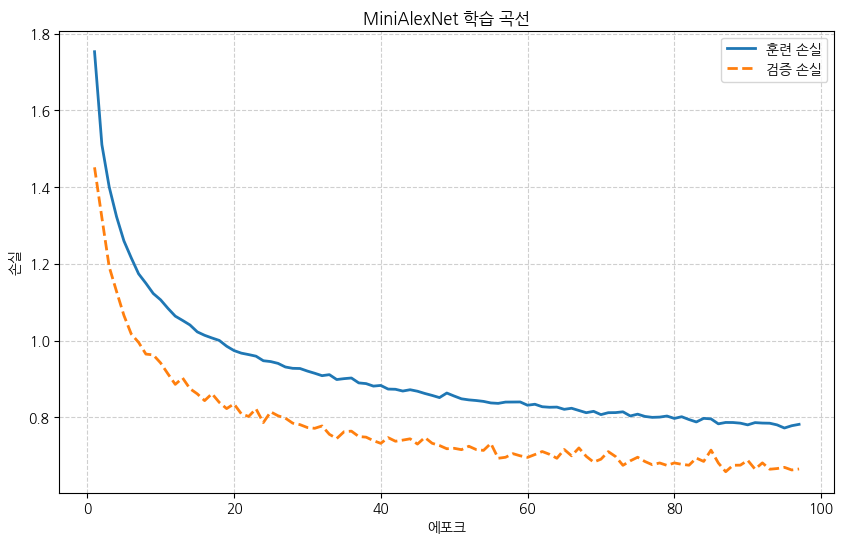

In [9]:
# 참고 - MiniAlexNet 모델 학습
import torch.optim as optim

# 모델마다 결과 재현을 위해 학습 전에 시드 고정
common.set_seed(SEED, deterministic=True)

# MiniAlexNet 모델 객체를 생성하고 학습 장치로 이동
model_alex = MiniAlexNet()
model_alex.to(device)                               

# 옵티마이저
optimizer = optim.Adam(model_alex.parameters(), lr=LR)

# 모델 학습
print('MiniAlexNet 학습')
log_alex = train_with_early_stopping(
    model_alex, train_loader, valid_loader, criterion, optimizer,
    EPOCHS, PATIENCE, device
)

log_alex.plot(title='MiniAlexNet 학습 곡선', y_label='손실')

> 학습 로그의 훈련 손실은 [표 8-2]의 훈련 손실과 다르다. 표의 값은 학습을 마친 후 조건(평가 모드, 증강 변환 미적용)을 바꿔 다시 계산한 값이기 때문이다. 드롭아웃은 학습 모드(`model.train()`)에서만 일부 뉴런의 출력을 0으로 만들고, 증강 변환은 원본을 변환해 일부러 맞히기 어렵게 만든다.

In [10]:
# 참고 - MiniAlexNet 모델의 평가

train_loss, train_acc = evaluate(model_alex, train_evaluate_loader, criterion, device)
test_loss, test_acc = evaluate(model_alex, test_loader, criterion, device)
print('MiniAlexNet 모델 평가(훈련 데이터셋)')
print(f'훈련 손실: {train_loss:.4f}, 정확도: {train_acc * 100:.2f}%')
print(f'MiniAlexNet 모델 평가(평가 데이터셋)')
print(f'평가 손실: {test_loss:.4f}, 정확도: {test_acc * 100:.2f}%')

MiniAlexNet 모델 평가(훈련 데이터셋)
훈련 손실: 0.5460, 정확도: 81.31%
MiniAlexNet 모델 평가(평가 데이터셋)
평가 손실: 0.6633, 정확도: 77.41%


MiniVGGNet 학습


 에포크    훈련 손실    검증 손실    정확도(%)     시간
  1/200       1.9617       1.5949       39.22%     0:13


  2/200       1.5661       1.2944       52.18%     0:27


  3/200       1.3527       1.1312       59.18%     0:40


  4/200       1.2188       1.0420       61.13%     0:53


...

 51/200       0.3630       0.4955       84.39%    13:37


 52/200       0.3573       0.5209       84.15%    13:55


 53/200       0.3534       0.5189       84.01%    14:11


 54/200       0.3555       0.5261       83.54%    14:29


 55/200       0.3512       0.5121       83.99%    14:49
최적 에포크(45, 최소 검증 손실 0.4923)의 파라미터로 모델 복원


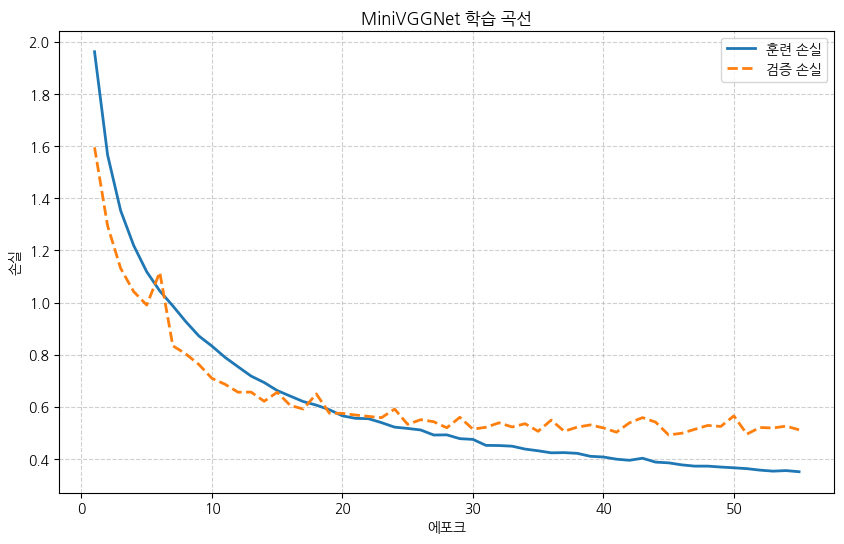

In [11]:
# 참고 - MiniVGGNet 모델 학습

# 모델마다 결과 재현을 위해 학습 전에 시드 고정
common.set_seed(SEED, deterministic=True)

# MiniVGGNet 모델 객체를 생성하고 학습 장치로 이동
model_vgg = MiniVGGNet()
model_vgg.to(device)                               
optimizer = optim.Adam(model_vgg.parameters(), lr=LR)

# 모델 학습
print('MiniVGGNet 학습')
log_vgg = train_with_early_stopping(
    model_vgg, train_loader, valid_loader, criterion, optimizer,
    EPOCHS, PATIENCE, device
)

log_vgg.plot(title='MiniVGGNet 학습 곡선', y_label='손실')

In [12]:
# 참고 - MiniVGGNet 모델의 평가

train_loss, train_acc = evaluate(model_vgg, train_evaluate_loader, criterion, device)
test_loss, test_acc = evaluate(model_vgg, test_loader, criterion, device)
print('MiniVGGNet 모델 평가(훈련 데이터셋)')
print(f'훈련 손실: {train_loss:.4f}, 정확도: {train_acc * 100:.2f}%')
print(f'MiniVGGNet 모델 평가(평가 데이터셋)')
print(f'평가 손실: {test_loss:.4f}, 정확도: {test_acc * 100:.2f}%')

MiniVGGNet 모델 평가(훈련 데이터셋)
훈련 손실: 0.2818, 정확도: 90.05%
MiniVGGNet 모델 평가(평가 데이터셋)
평가 손실: 0.5046, 정확도: 83.74%


- 본문 [표 8-2]의 수치(MiniAlexNet 98 에포크 / 81.61% / 77.55%, MiniVGGNet 43 에포크 / 89.44% / 83.38%)와 비교해 보자.
- 두 모델의 평가에서 다음 결론을 끌어낼 수 있다.
    - **성능과 비용의 효율적 선택**: 1 에포크 학습 시간은 `MiniVGGNet`이 조금 더 길지만, 정확도가 향상된 데다 최적 에포크가 줄어 전체 학습 시간은 절반 가까이 줄었다.
    - **과소적합의 극복**: 훈련 손실과 평가 손실의 차이가 `MiniVGGNet`에서 더 커져 과적합이 심해진 것처럼 보이지만, 평가 정확도가 오히려 6%p 가량 개선된 점을 함께 보면 `MiniAlexNet`이 과소적합 상황이었음을 알 수 있다.

## 정리

- VGGNet은 3x3 크기의 작은 필터를 반복해 깊게 쌓는 전략으로, 큰 필터 하나가 감당하는 수용 영역을 여러 개의 작은 필터로 대체한다.
- 합성곱 계층을 세 배 더 쌓은 `MiniVGGNet`의 파라미터 수는 크게 늘지 않는다. 작은 필터로 통일한 효과다.
- 더 깊은 모델은 더 많은 비선형성을 통과해 특징을 다양하게 조합할 수 있어, 학습 시간과 성능 모두에서 유리하다.